# Script to plot Power Spectra and write the Beta Profile Excel sheet

In [2]:
import os
import sys
import importlib
from importlib import reload 
from dataclasses import dataclass, field, fields
from itertools import compress
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import scipy
import scipy.io as sio
from scipy import signal
from scipy.signal import spectrogram, butter, filtfilt, freqz
try:
    from scipy.signal import hann
except:
    from scipy.signal.windows import hann
from scipy.integrate import simps
from scipy import stats

import pickle
import json
import csv

#mne
import mne_bids
import mne
from mne.time_frequency import tfr_morlet 
from mne.stats import permutation_cluster_test
from mne.preprocessing import ICA, create_ecg_epochs


### Load PyPerceive locally: dev branch (following PyPerceive README rules) 

In [ ]:
# ########################################### 1. Define your username: ###########################################
# username = "jenniferbehnke" #### input required here 

# user_path = os.getcwd()

# # get the path only to your username
# while True:
#     user_path, tail = os.path.split(user_path)
#     if tail == username:
#         user_path = os.path.join(user_path, tail)
#         break
#     if user_path == os.path.sep:  # If we reach the root directory
#         raise ValueError(f"Directory '{username}' not found in the path")

# ########################################### 2. Define your path to Import PyPerceive: ###########################################
# PyPerceive_path = os.path.join(user_path, 'code', 'PyPerceive', 'code') #### input required here  
# print(PyPerceive_path)
# sys.path.append(PyPerceive_path)
# os.chdir(PyPerceive_path)

# from PerceiveImport.classes import (
#     main_class, modality_class, metadata_class,
#     session_class, condition_class, task_class,
#     contact_class, run_class
# )

# import PerceiveImport.methods.load_rawfile as load_rawfile
# import PerceiveImport.methods.find_folders as PyPerceive_find_folders
# import PerceiveImport.methods.metadata_helpers as metaHelpers


# # ########################################### 3. Define your path to the Beta_profile Repository: ###########################################
# beta_profile_path = os.path.join(user_path, 'code', 'Beta_profile_project', 'Beta_profile') #### input required here  

# sys.path.append(beta_profile_path)
# os.chdir(beta_profile_path)

# print(beta_profile_path)
# # utils
# import src.beta_profile.utils.find_folders as find_folders
# import src.beta_profile.utils.io as io

# # tfr
# import src.beta_profile.beta_profile.tfr_preprocessing as tfr

# # plots
# import src.beta_profile.beta_profile.power_spectra_plots as power_spectra


# importlib.reload(find_folders)
# importlib.reload(io)
# importlib.reload(tfr)
# importlib.reload(power_spectra)

/Users/jenniferbehnke/code/PyPerceive/code
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile


<module 'src.beta_profile.beta_profile.power_spectra_plots' from '/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/beta_profile/power_spectra_plots.py'>

### Load PyPerceive from environment: dev_Jenny branch (find_folders path hardcoded) -> path: "code"/"PyPerceive_Project"/"PyPerceive"

In [31]:
from PerceiveImport.classes import (
    main_class, modality_class, metadata_class,
    session_class, condition_class, task_class,
    contact_class, run_class
)

import PerceiveImport.methods.load_rawfile as load_rawfile
import PerceiveImport.methods.find_folders as PyPerceive_find_folders
import PerceiveImport.methods.metadata_helpers as metaHelpers

# utils
import beta_profile.utils.find_folders as find_folders
import beta_profile.utils.io as io
import beta_profile.utils.sub_session_dict as sub_session_dict

# tfr
import beta_profile.beta_profile.tfr_preprocessing as tfr
import beta_profile.beta_profile.tfr_plots as tfr_plots

# plots
import beta_profile.beta_profile.power_spectra_plots as power_spectra
import beta_profile.beta_profile.time_series_ecg_artifact as time_series

# beta profile
import beta_profile.beta_profile.calculate_features as calculate_features


importlib.reload(find_folders)
importlib.reload(io)
importlib.reload(tfr)
importlib.reload(power_spectra)
importlib.reload(calculate_features)
importlib.reload(time_series)
importlib.reload(tfr_plots)
importlib.reload(sub_session_dict)

<module 'beta_profile.utils.sub_session_dict' from '/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/sub_session_dict.py'>

## Time Series Plots: check for ECG artifact

Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.
Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.


/Users/jenniferbehnke/anaconda3/envs/beta_profile/lib/python3.12/site-packages/pymatreader/utils.py:238: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn('Complex objects (like classes) are not supported. '
/Users/jenniferbehnke/anaconda3/envs/beta_profile/lib/python3.12/site-packages/pymatreader/utils.py:232: UserWarning: pymatreader cannot import Matlab string variables. Please convert these variables to char arrays in Matlab.
  warn('pymatreader cannot import Matlab string variables. '
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: Ru

Creating RawArray with float64 data, n_channels=3, n_times=5313
    Range : 0 ... 5312 =      0.000 ...    21.248 secs
Ready.


/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of channel LFP_Stn_1_A_2_A_LEFT_SEGMENT. Making it a MISC channel.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of channel LFP_Stn_1_B_2_B_LEFT_SEGMENT. Making it a MISC channel.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of chan

Figure unfiltered_time_series_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-Ring.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Figure unfiltered_time_series_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-SegmInter.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Figure unfiltered_time_series_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-SegmIntra.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.


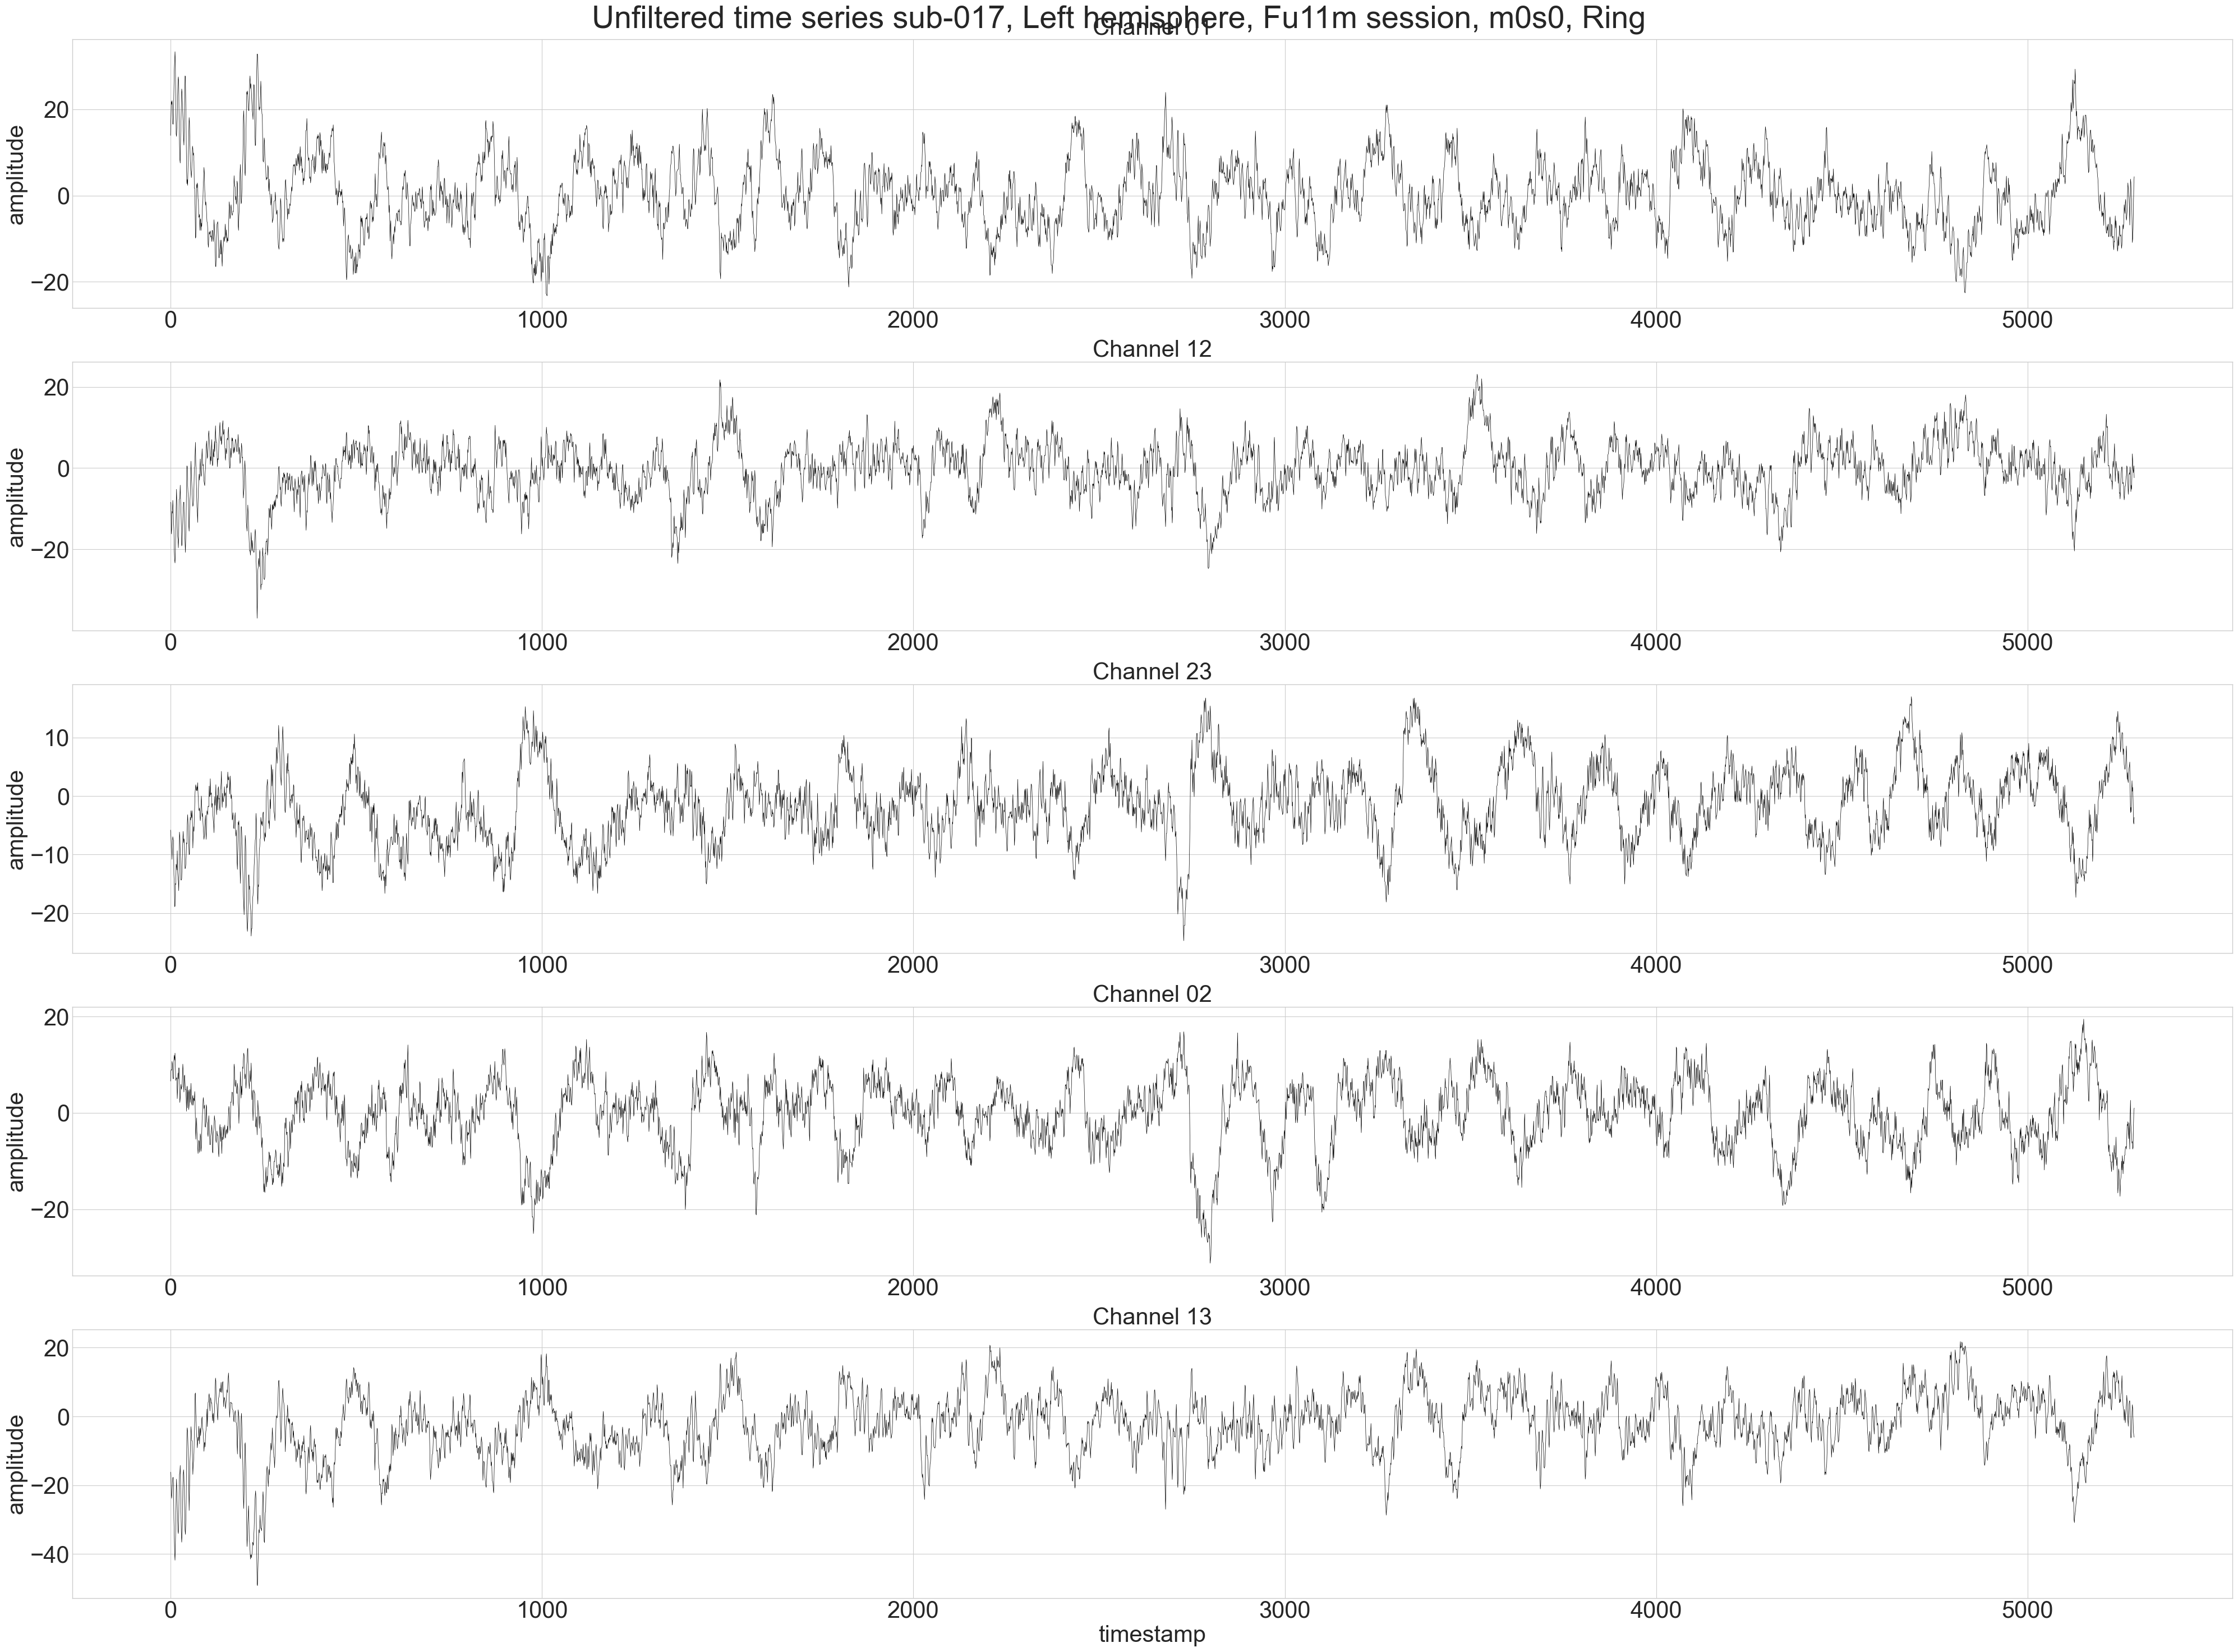

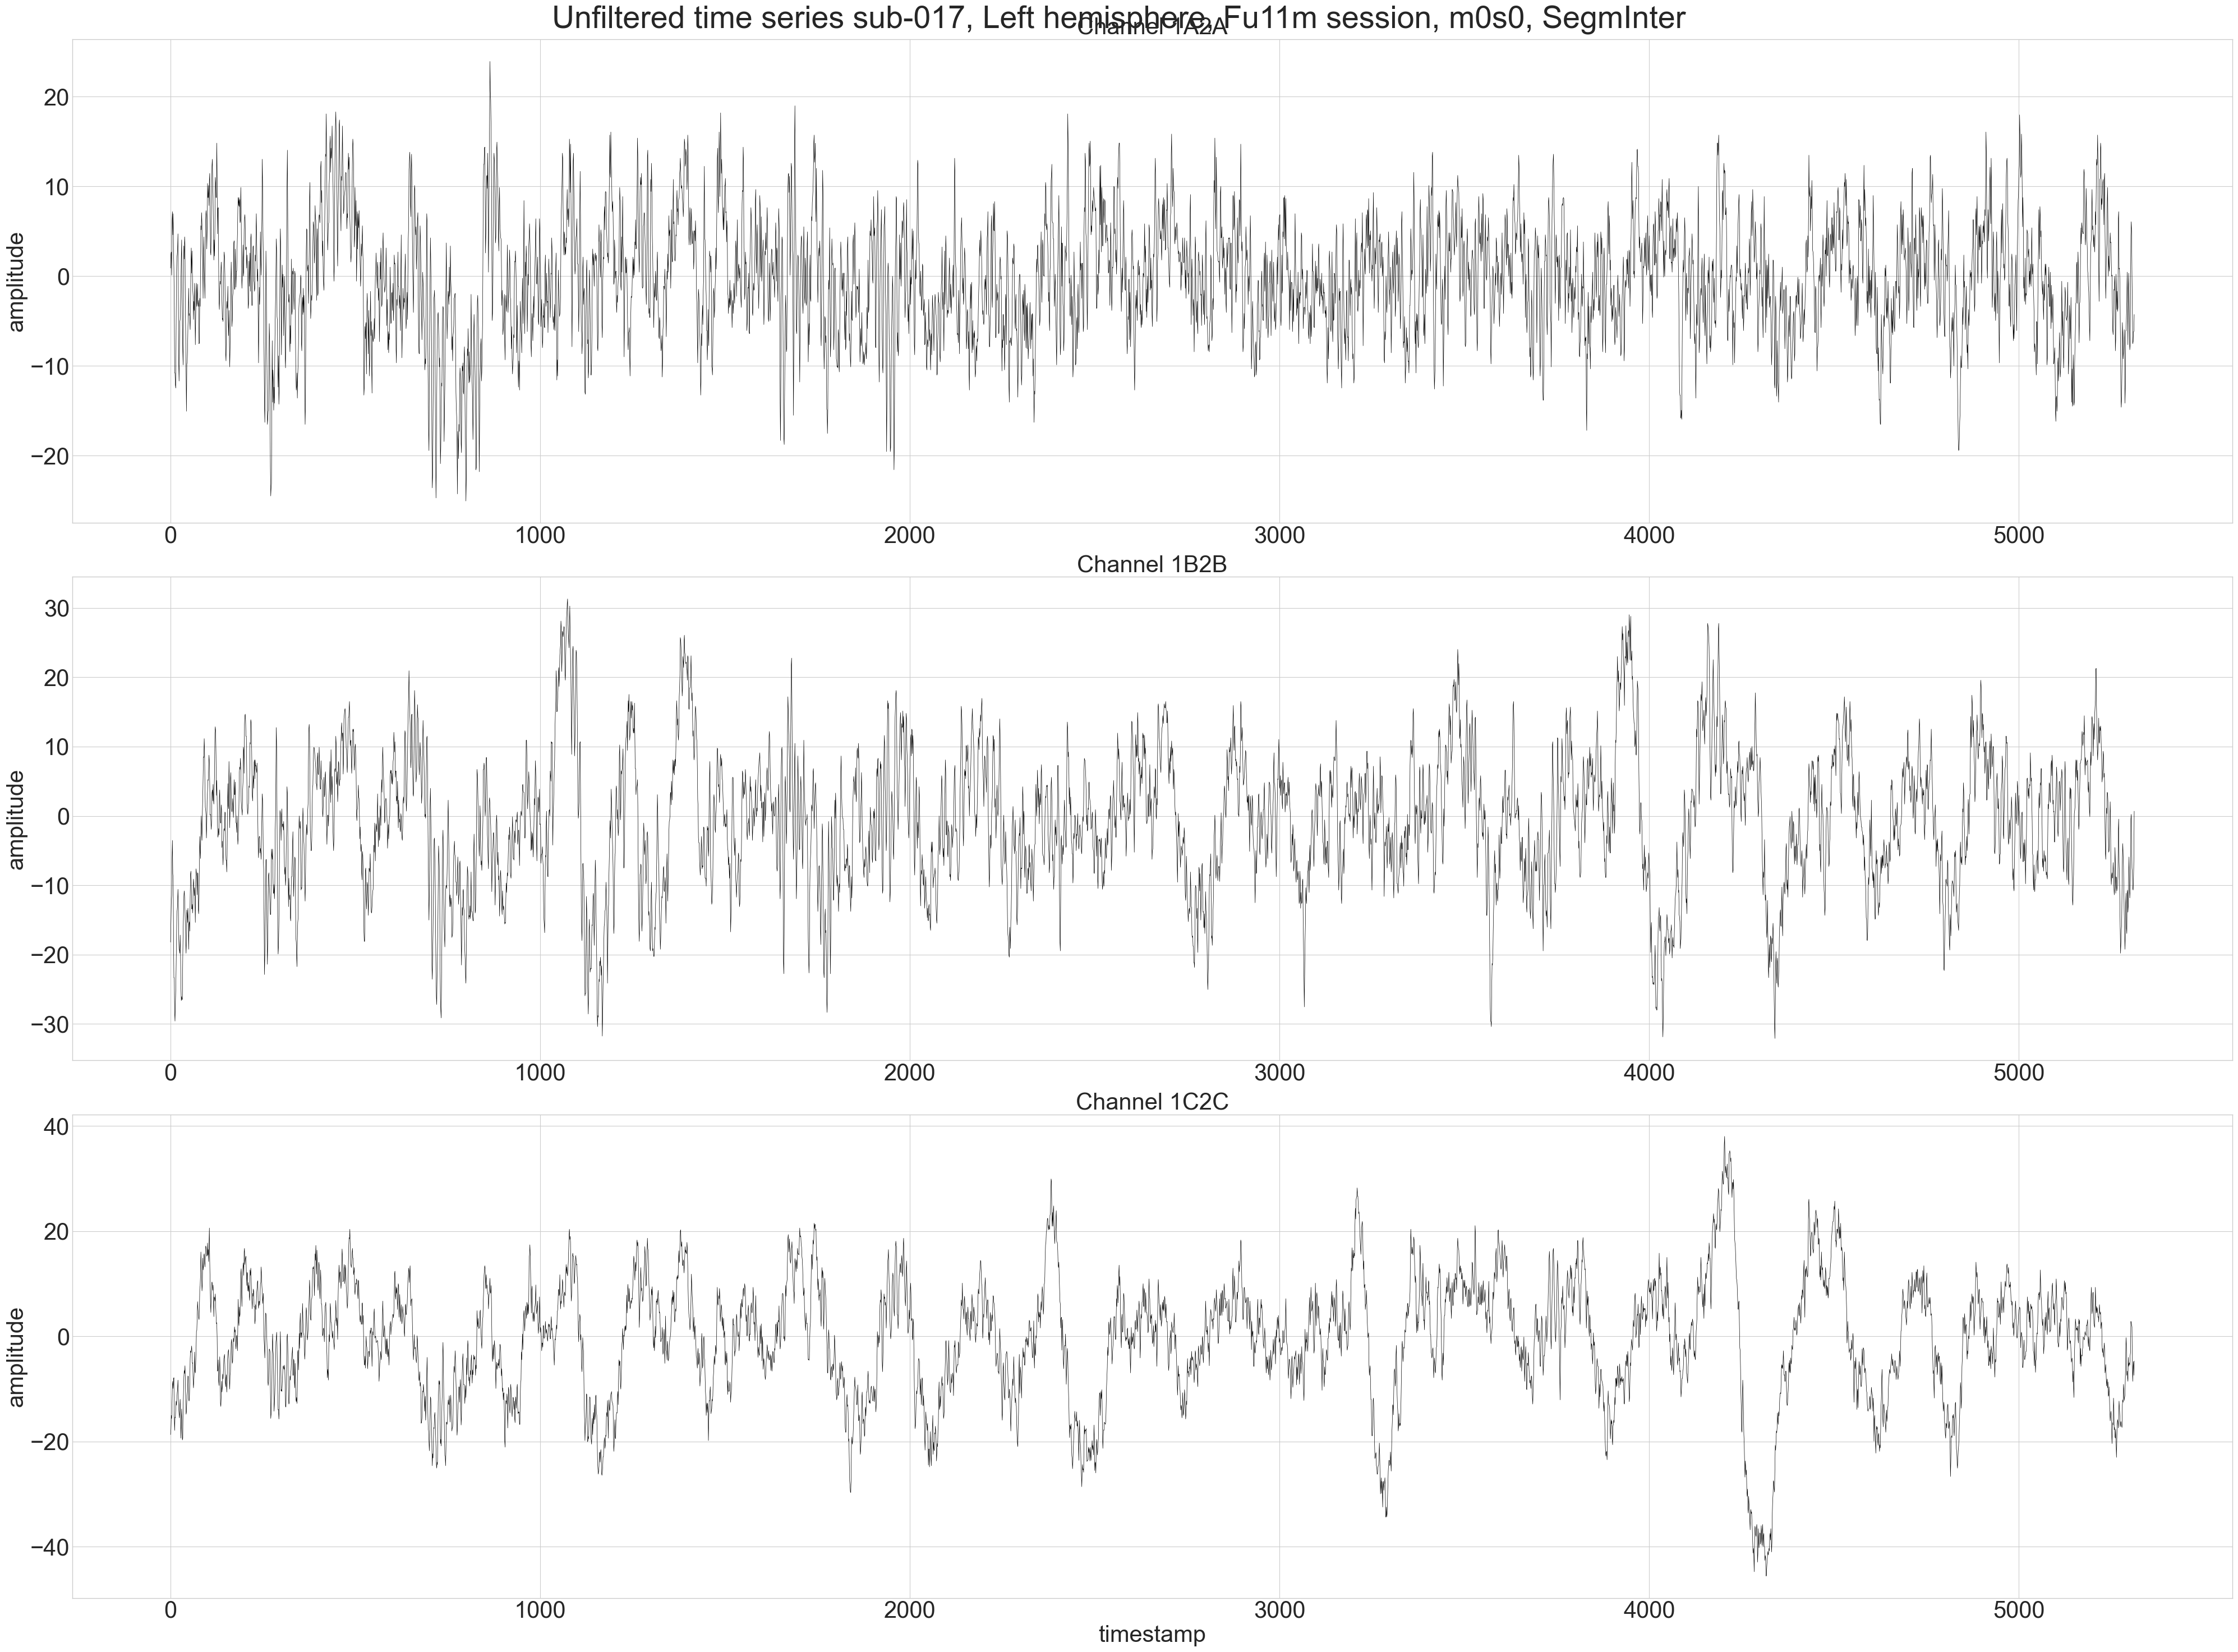

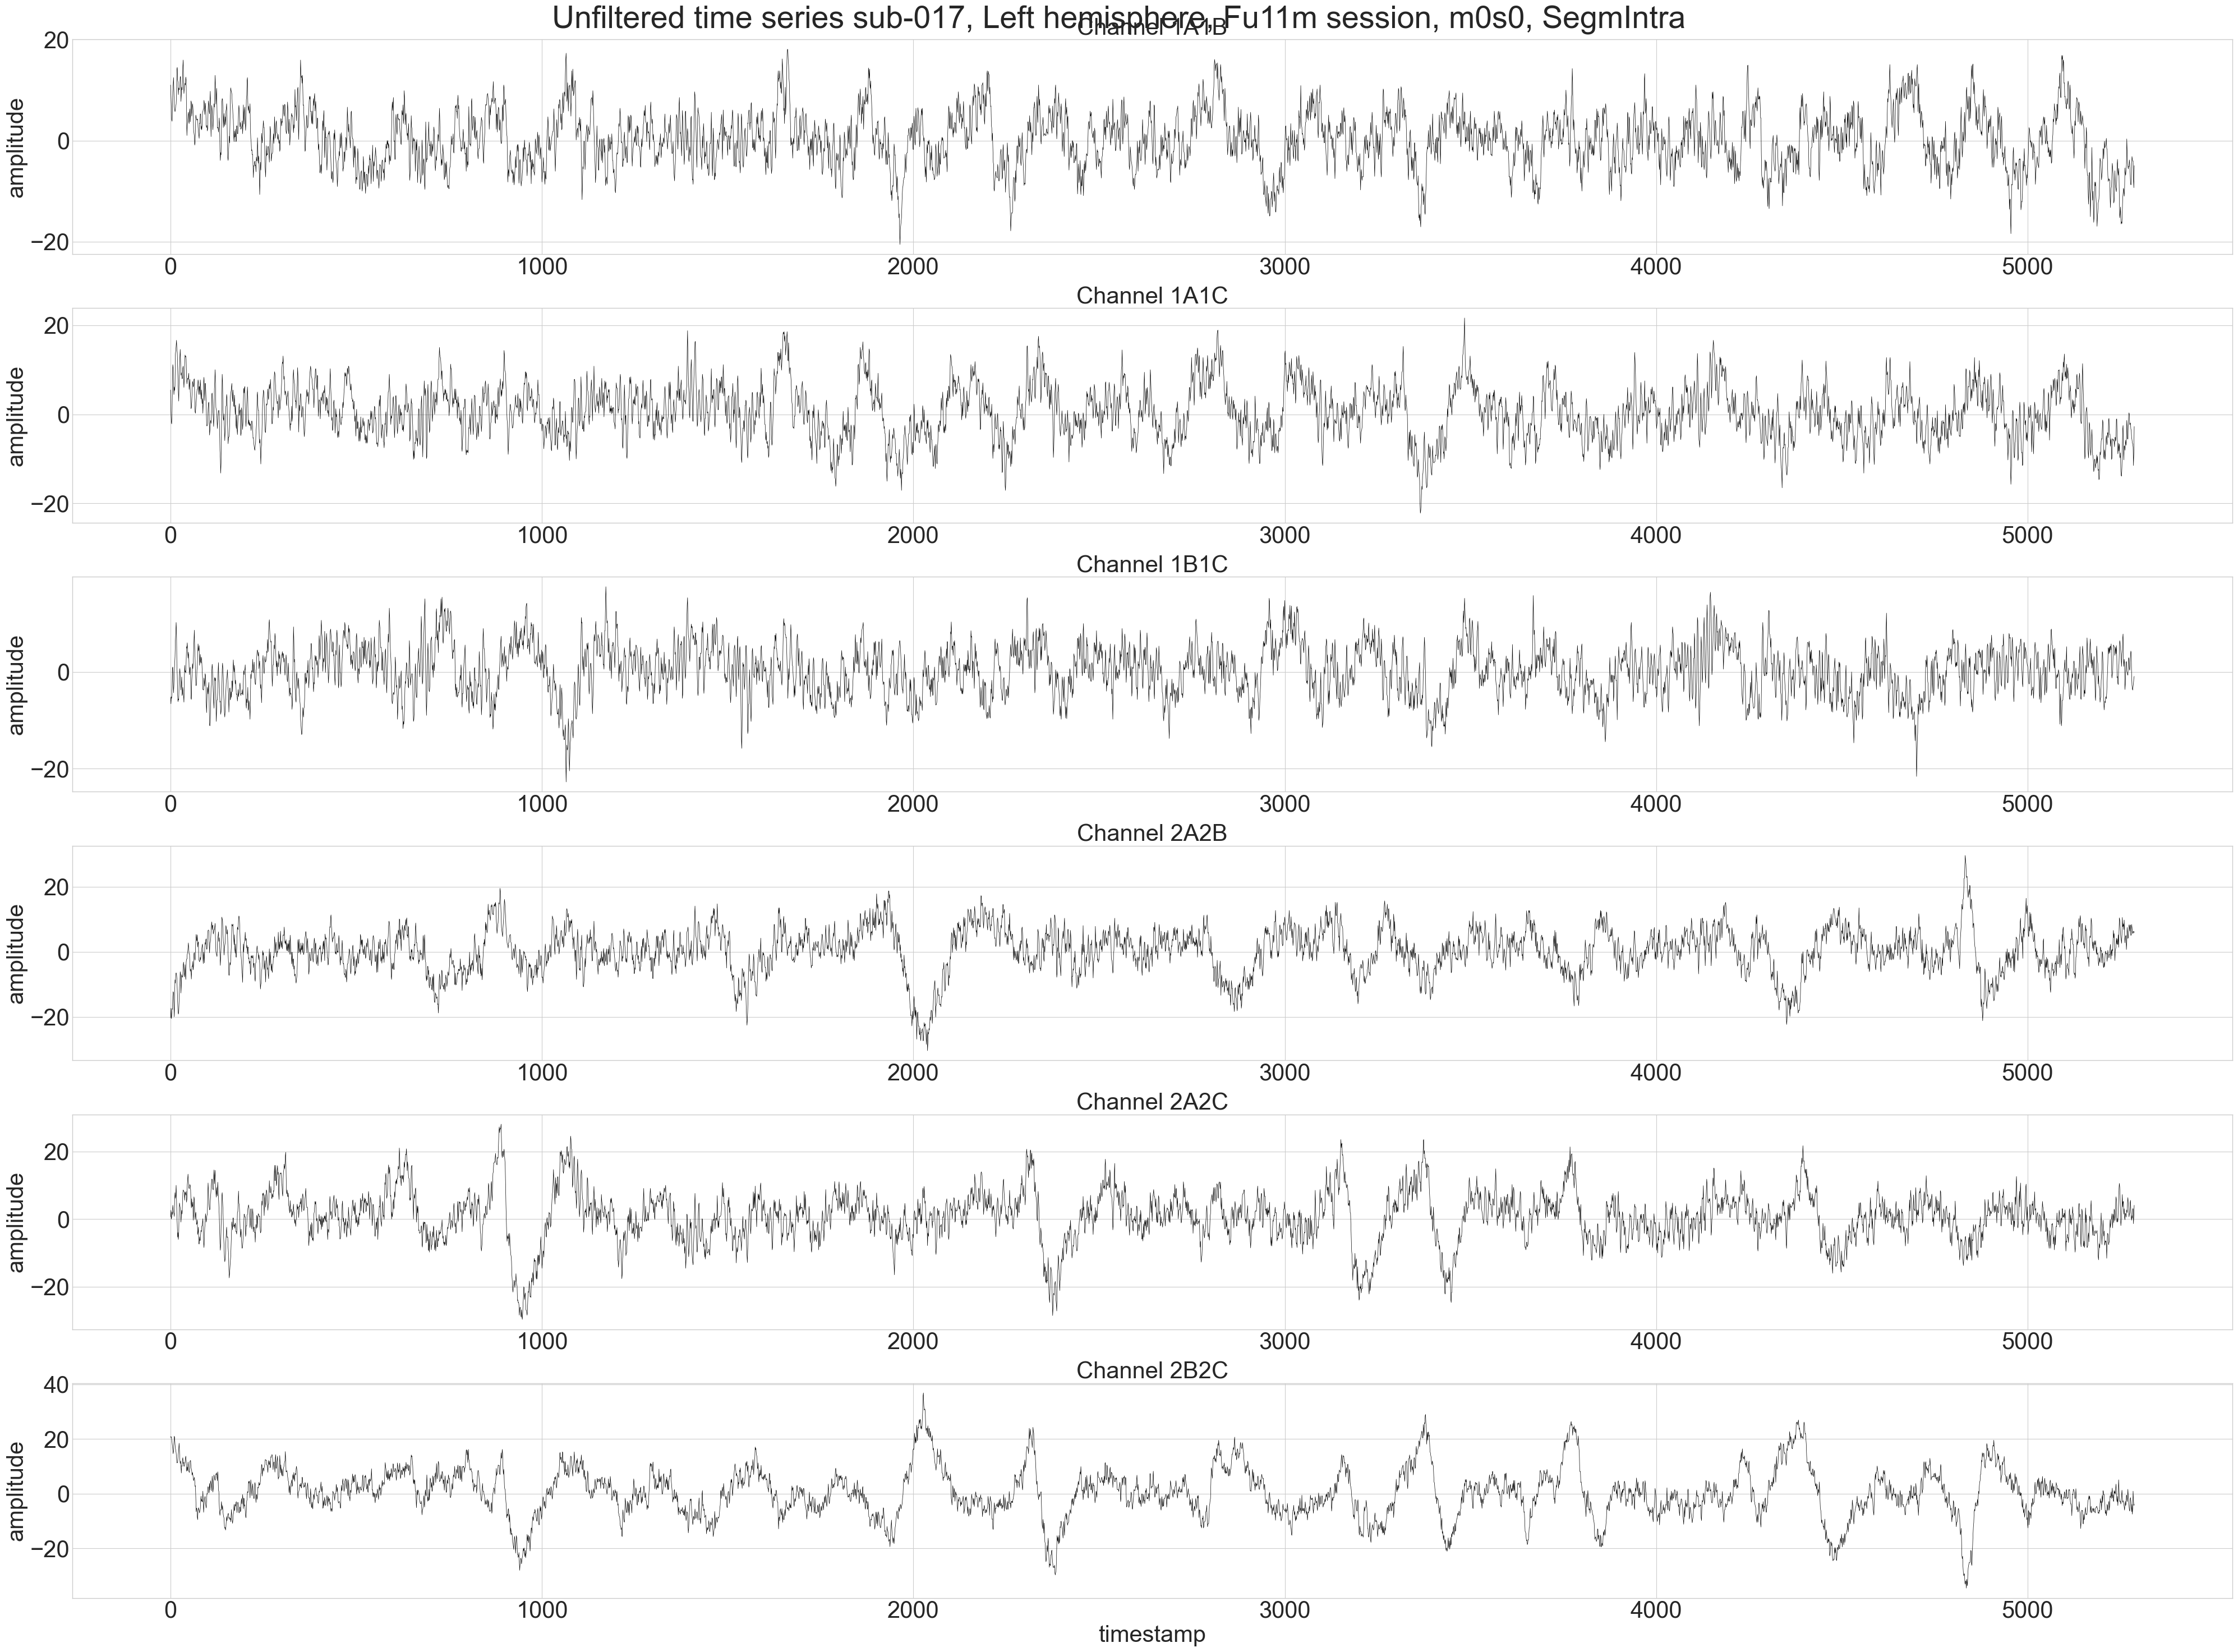

In [8]:
plot_raw_time_series = time_series.plot_ieeg_data(
    sub="017",
    session="Fu11m",
    condition="m0s0",
    hemisphere="Left"
)

## Power Spectra

This function plots 2 Power spectra Figures: 
- Ring_neighbours: channels 01, 12, 23
- Ring_sandwich: channels 02, 13
- Segm: all segmental bipolar channels

Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.
Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.


/Users/jenniferbehnke/anaconda3/envs/beta_profile/lib/python3.12/site-packages/pymatreader/utils.py:238: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn('Complex objects (like classes) are not supported. '
/Users/jenniferbehnke/anaconda3/envs/beta_profile/lib/python3.12/site-packages/pymatreader/utils.py:232: UserWarning: pymatreader cannot import Matlab string variables. Please convert these variables to char arrays in Matlab.
  warn('pymatreader cannot import Matlab string variables. '
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: Ru

Creating RawArray with float64 data, n_channels=3, n_times=5313
    Range : 0 ... 5312 =      0.000 ...    21.248 secs
Ready.


/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of channel LFP_Stn_1_A_2_A_RIGHT_SEGMENT. Making it a MISC channel.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of channel LFP_Stn_1_B_2_B_RIGHT_SEGMENT. Making it a MISC channel.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of ch

Figure Power_Spectra_sub-017_hem-Right_ses-Fu11m_cond-m0s0_group-Ring_neighbours.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Figure Power_Spectra_sub-017_hem-Right_ses-Fu11m_cond-m0s0_group-Ring_sandwich.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Figure Power_Spectra_sub-017_hem-Right_ses-Fu11m_cond-m0s0_group-Segm.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.
Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.


/Users/jenniferbehnke/anaconda3/envs/beta_profile/lib/python3.12/site-packages/pymatreader/utils.py:238: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn('Complex objects (like classes) are not supported. '
/Users/jenniferbehnke/anaconda3/envs/beta_profile/lib/python3.12/site-packages/pymatreader/utils.py:232: UserWarning: pymatreader cannot import Matlab string variables. Please convert these variables to char arrays in Matlab.
  warn('pymatreader cannot import Matlab string variables. '
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: Ru

Creating RawArray with float64 data, n_channels=3, n_times=5313
    Range : 0 ... 5312 =      0.000 ...    21.248 secs
Ready.


/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of channel LFP_Stn_1_A_2_A_LEFT_SEGMENT. Making it a MISC channel.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of channel LFP_Stn_1_B_2_B_LEFT_SEGMENT. Making it a MISC channel.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of chan

Figure Power_Spectra_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-Ring_neighbours.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Figure Power_Spectra_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-Ring_sandwich.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Figure Power_Spectra_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-Segm.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.


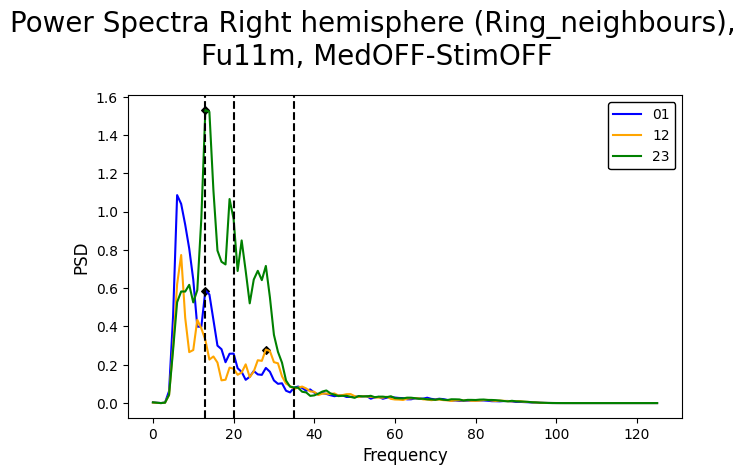

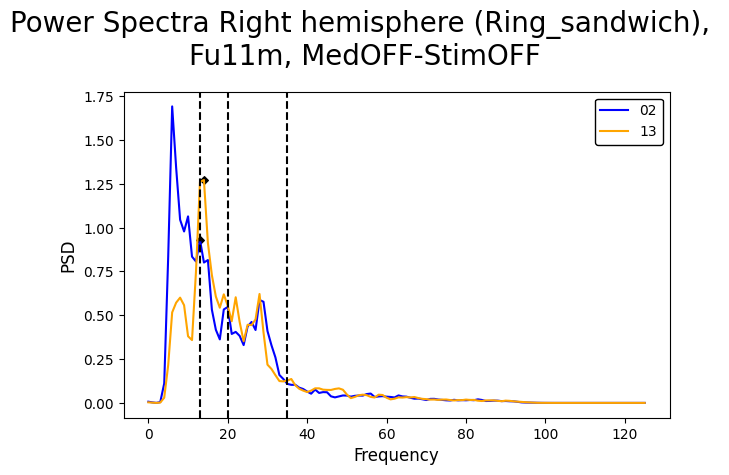

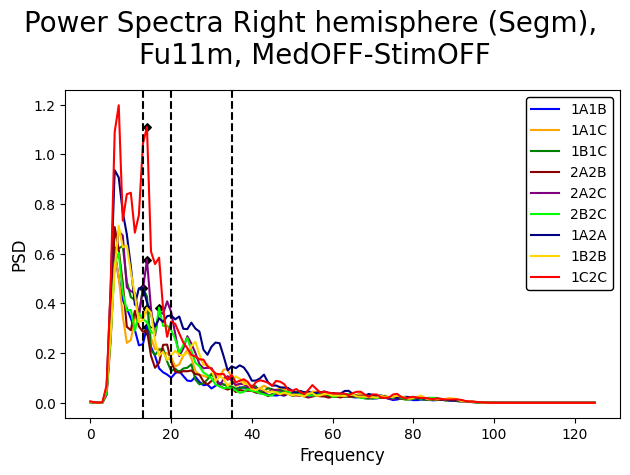

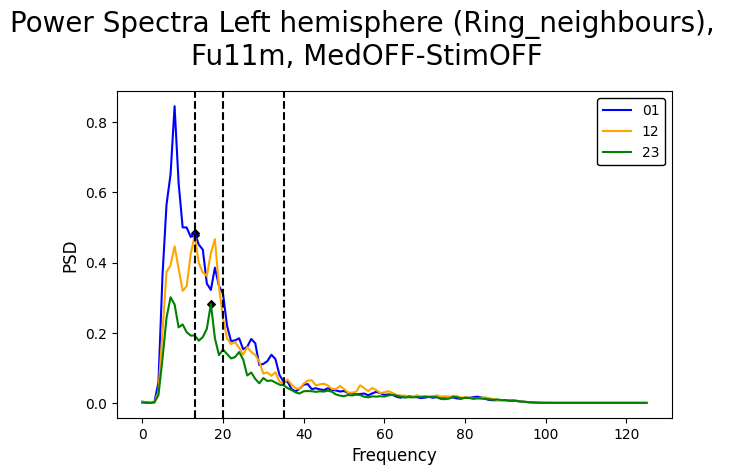

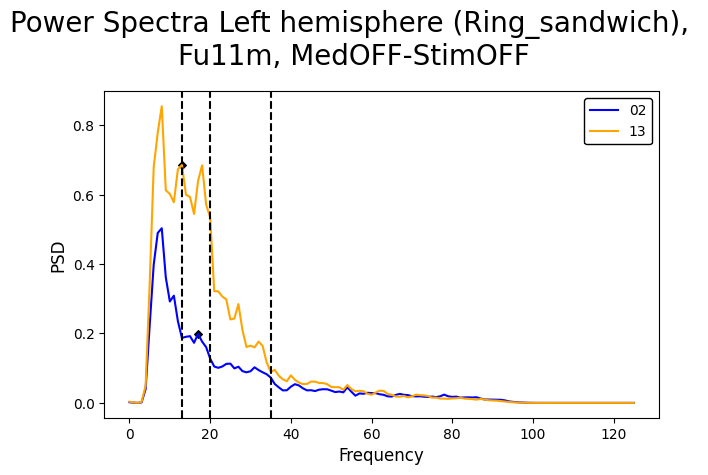

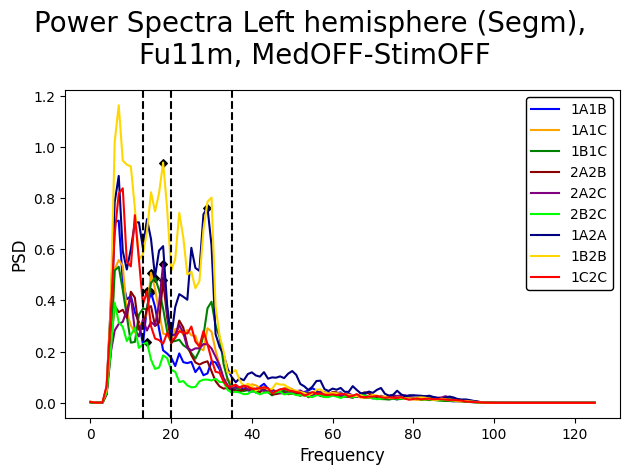

In [7]:
# band-pass filtered 5-95 Hz
# fourier transform: 1Hz resolution, 1 sec window length
HEMISPHERES = ["Right", "Left"]

for hem in HEMISPHERES:

    power_spectra_plot = power_spectra.plot_power_spectra(
        sub="017",
        session="Fu11m",
        condition="m0s0",
        hemisphere=hem
    )


## Time frequency plots

Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.
Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.


/Users/jenniferbehnke/anaconda3/envs/beta_profile/lib/python3.12/site-packages/pymatreader/utils.py:238: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn('Complex objects (like classes) are not supported. '
/Users/jenniferbehnke/anaconda3/envs/beta_profile/lib/python3.12/site-packages/pymatreader/utils.py:232: UserWarning: pymatreader cannot import Matlab string variables. Please convert these variables to char arrays in Matlab.
  warn('pymatreader cannot import Matlab string variables. '
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: Ru

Creating RawArray with float64 data, n_channels=3, n_times=5313
    Range : 0 ... 5312 =      0.000 ...    21.248 secs
Ready.


/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: The supplied FieldTrip structure does not have an elec or grad field. No channel locations will extracted and the kind of channel might be inaccurate.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of channel LFP_Stn_1_A_2_A_LEFT_SEGMENT. Making it a MISC channel.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of channel LFP_Stn_1_B_2_B_LEFT_SEGMENT. Making it a MISC channel.
  data = read_raw_fieldtrip(f, info={}, data_name="data")
/Users/jenniferbehnke/code/Beta_profile_project/Beta_profile/src/beta_profile/utils/io.py:152: RuntimeWarning: Cannot guess the correct type of chan

Figure Time_Frequency_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-Ring_unfiltered.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Figure Time_Frequency_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-SegmInter_unfiltered.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.
Figure Time_Frequency_sub-017_hem-Left_ses-Fu11m_cond-m0s0_group-SegmIntra_unfiltered.jpg 
were written in: /Users/jenniferbehnke/Charité - Universitätsmedizin Berlin/AG Bewegungsstörungen - Percept - Percept_Data_structured/beta_data_v2/sub-017.


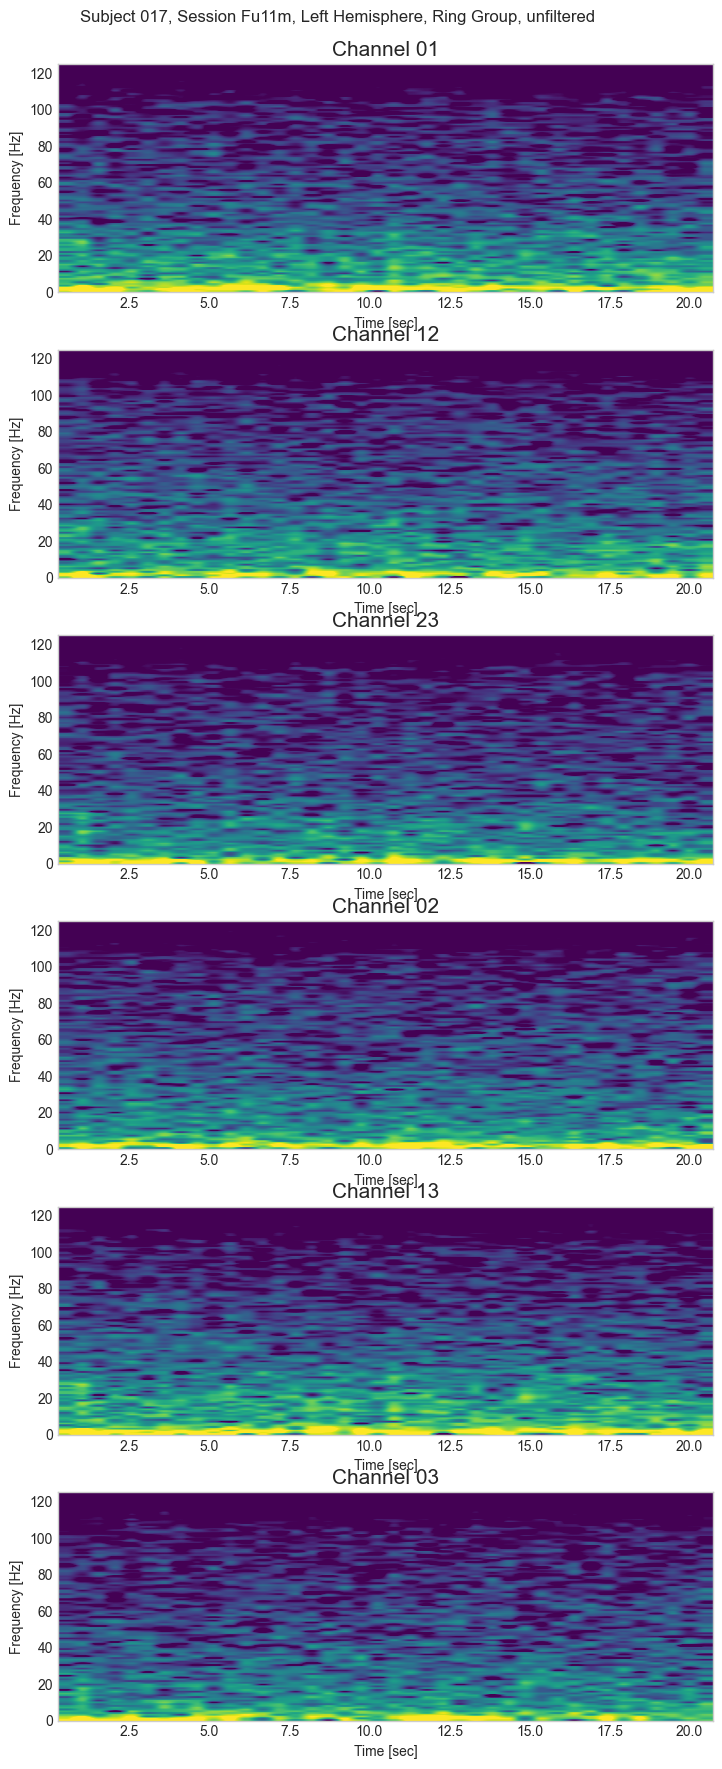

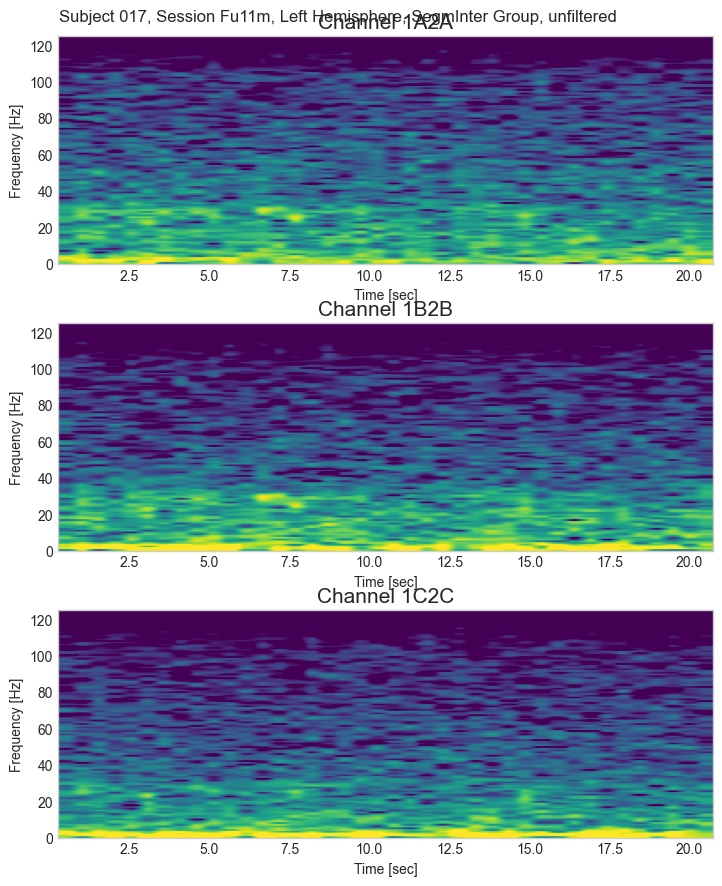

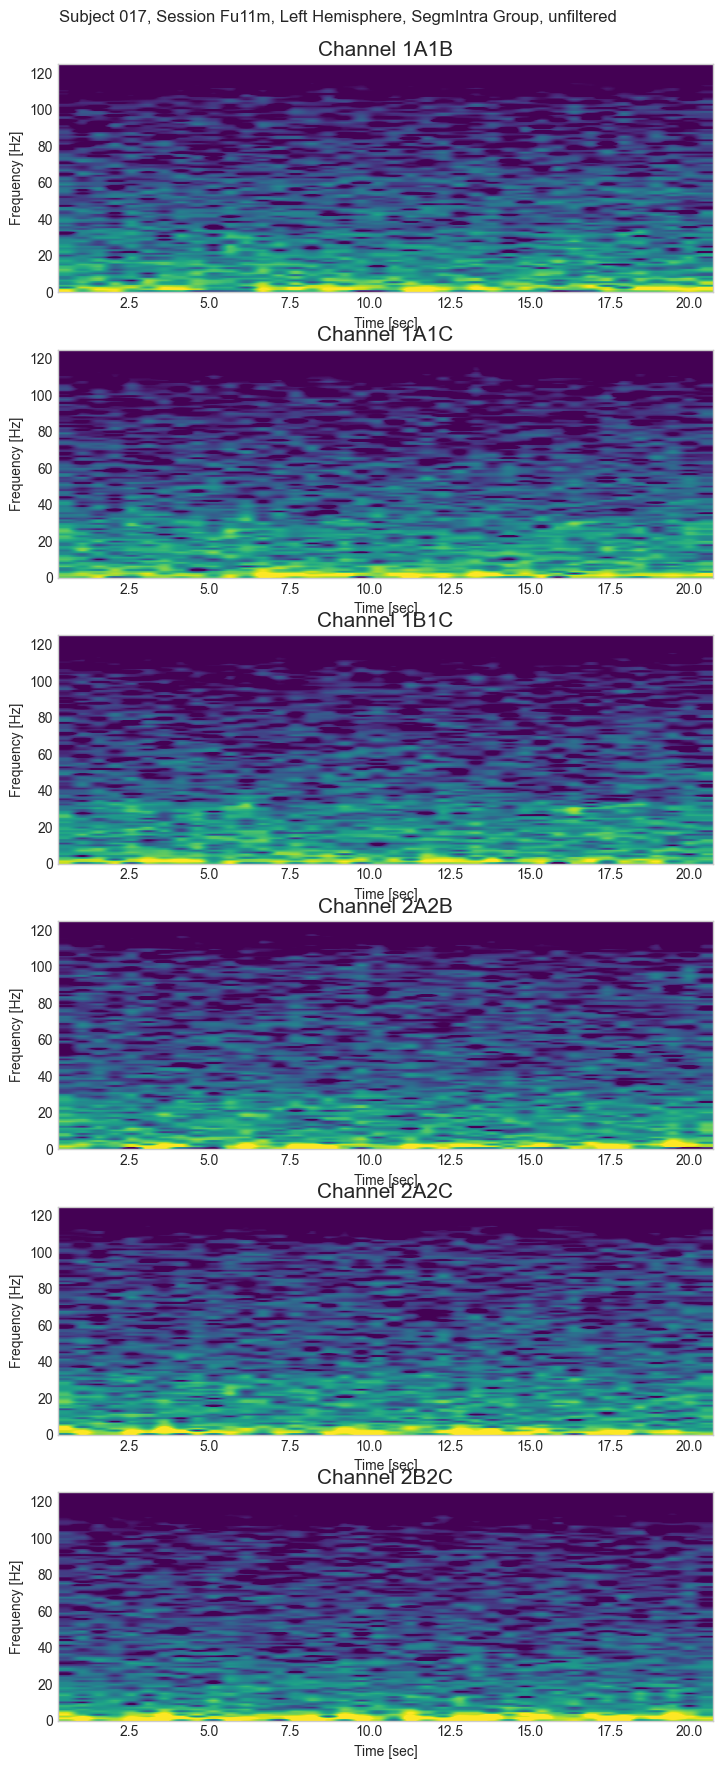

In [25]:
time_frequency = tfr_plots.plot_time_frequency(sub="017",
                                               session="Fu11m",
                                               condition="m0s0",
                                               hemisphere="Left",
                                               filtered="unfiltered")


## Beta Profile Excel Sheet

In [9]:
beta_file = calculate_features.write_beta_profile(
    sub="077",
    session="fu12m",
    condition="m0s0",
    beta_range="low_beta"
)

Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.
Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5250
    Range : 0 ... 5249 =      0.000 ...    20.996 secs
Ready.
Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.
Creating RawArray with float64 data, n_channels=6, n_times=5288
    Range : 0 ... 5287 =      0.000 ...    21.148 secs
Ready.
Creating RawArray with float64 data, n_channels=3, n_times=5125
    Range : 0 ... 5124 =      0.000 ...    20.496 secs
Ready.


In [33]:
beta_file["Left_Ring"]

,channel,f_range,power_in_f_range,ring_max_beta_CF,peak_4Hz_power,beta_rank,rel_beta_peak_power
0,23,high_beta,0.146427,21,0.239276,1.0,1.000000
0,13,high_beta,0.159799,21,0.209401,2.0,0.875142
0,02,high_beta,0.121885,21,0.146314,3.0,0.611486
0,12,high_beta,0.085286,21,0.105383,4.0,0.440422
0,01,high_beta,0.108176,21,0.099876,5.0,0.417408


In [34]:
beta_file["Left_Segm"]

,channel,f_range,power_in_f_range,ring_max_beta_CF,peak_4Hz_power,beta_rank,rel_beta_peak_power
0,2A2C,high_beta,0.240387,21,0.248209,1.0,1.000000
0,1A2A,high_beta,0.202490,21,0.224273,2.0,0.903565
0,1A1C,high_beta,0.137151,21,0.135697,3.0,0.546704
0,2A2B,high_beta,0.116190,21,0.135467,4.0,0.545779
0,2B2C,high_beta,0.118617,21,0.122748,5.0,0.494537
0,1C2C,high_beta,0.086063,21,0.117455,6.0,0.473212
0,1B1C,high_beta,0.139462,21,0.116991,7.0,0.471343
0,1B2B,high_beta,0.093055,21,0.105522,8.0,0.425132
0,1A1B,high_beta,0.092881,21,0.086304,9.0,0.347709


In [35]:
beta_file["Right_Ring"]

,channel,f_range,power_in_f_range,ring_max_beta_CF,peak_4Hz_power,beta_rank,rel_beta_peak_power
0,02,high_beta,0.472926,30,0.801270,1.0,1.000000
0,12,high_beta,0.385218,30,0.704387,2.0,0.879088
0,23,high_beta,0.325524,30,0.541752,3.0,0.676116
0,13,high_beta,0.279922,30,0.393412,4.0,0.490985
0,01,high_beta,0.124031,30,0.135671,5.0,0.169320


In [36]:
beta_file["Right_Segm"]

,channel,f_range,power_in_f_range,ring_max_beta_CF,peak_4Hz_power,beta_rank,rel_beta_peak_power
0,1A2A,high_beta,0.501242,30,0.792066,1.0,1.000000
0,2A2C,high_beta,0.310364,30,0.427494,2.0,0.539720
0,1B2B,high_beta,0.289273,30,0.425623,3.0,0.537359
0,1C2C,high_beta,0.293952,30,0.338474,4.0,0.427330
0,2A2B,high_beta,0.234301,30,0.319970,5.0,0.403969
0,1A1C,high_beta,0.177571,30,0.235358,6.0,0.297144
0,2B2C,high_beta,0.154312,30,0.203740,7.0,0.257226
0,1B1C,high_beta,0.152857,30,0.188620,8.0,0.238137
0,1A1B,high_beta,0.113177,30,0.118635,9.0,0.149779


## Main Function to plot and write Excel sheets of a list of subjects

In [32]:
sub_session_dict = io.find_sessions_per_sub(condition="MedOff", modality="survey")
sub_session_dict = sub_session_dict[1]

In [33]:
sub_session_dict

{'sub-007': ['Fu14m'],
 'sub-011': ['Fu37m'],
 'sub-013': ['Fu31m'],
 'sub-014': ['Fu12m'],
 'sub-015': ['Fu05m'],
 'sub-016': ['Fu25m'],
 'sub-017': ['Fu11m', 'Fu03m'],
 'sub-019': ['Fu12m', 'Fu02m', 'Fu23m'],
 'sub-020': ['Fu22m', 'Fu13m'],
 'sub-021': ['Fu12m', 'Fu03m'],
 'sub-022': ['Fu00m'],
 'sub-023': ['Fu13m'],
 'sub-024': ['Fu00m', 'Fu26m', 'Fu11m', 'Fu03m', 'Fu17m'],
 'sub-025': ['Fu00m', 'Fu12m', 'Fu04m'],
 'sub-026': ['Fu12m', 'Fu03m'],
 'sub-028': ['Fu00m', 'Fu12m', 'Fu24m'],
 'sub-029': ['Fu00m', 'Fu16m', 'Fu25m', 'Fu03m'],
 'sub-030': ['Fu00m', 'Fu12m', 'Fu03m'],
 'sub-031': ['Fu00m', 'Fu03m'],
 'sub-032': ['Fu00m', 'Fu03m'],
 'sub-033': ['Fu12m', 'Fu24m', 'Fu03m', 'Fu17m'],
 'sub-036': ['Fu12m', 'Fu24m', 'Fu18m'],
 'sub-038': ['Fu00m', 'Fu03m'],
 'sub-039': ['Fu13m'],
 'sub-040': ['Fu12m', 'Fu03m'],
 'sub-041': ['Fu17m'],
 'sub-042': ['Fu13m'],
 'sub-043': ['Fu13m'],
 'sub-044': ['Fu13m'],
 'sub-045': ['Fu12m', 'Fu03m'],
 'sub-047': ['Fu00m', 'Fu12m'],
 'sub-048': ['Fu0

In [46]:
# band-pass filtered 5-95 Hz
# fourier transform: 1Hz resolution, 1 sec window length
HEMISPHERES = ["Right", "Left"]
FREQ_BANDS = ["beta", "high_beta", "low_beta"]

#sub_list = sub_session_dict.keys()
sub_list = sub_session_dict.get_all_included_subjects()

for sub in sub_list:

    session = sub_session_dict.get_sub_sessions(sub=sub)
    #for ses in sub_session_dict[sub]:

    for hem in HEMISPHERES:

        plot_raw_time_series = time_series.plot_ieeg_data(
        sub=sub,
        session=session,
        condition="m0s0",
        hemisphere=hem
        )

        power_spectra_plot = power_spectra.plot_power_spectra(
            sub=sub,
            session=session,
            condition="m0s0",
            hemisphere=hem
        )

        time_frequency = tfr_plots.plot_time_frequency(sub=sub,
                                                    session=session,
                                                    condition="m0s0",
                                                    hemisphere=hem,
                                                    filtered="unfiltered")

        for fq_band in FREQ_BANDS:

            beta_file = calculate_features.write_beta_profile(
                sub=sub,
                session=session,
                condition="m0s0",
                beta_range=fq_band)

